In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_data.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
df.shape

(392692, 9)

In [4]:
latest_date = df["InvoiceDate"].max()

In [5]:
prediction_window = 3

In [7]:
cutoff_date = latest_date - pd.DateOffset(
    months=prediction_window
)

In [8]:
observation_df = df[
    df["InvoiceDate"] < cutoff_date
].copy()

future_df = df[
    df["InvoiceDate"] >= cutoff_date
].copy()

In [11]:
observation_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
recency = (
    latest_date -
    observation_df.groupby("CustomerID")["InvoiceDate"].max()
).dt.days

In [13]:
recency.head()

CustomerID
12346.0    325
12347.0    129
12348.0    248
12350.0    309
12352.0    261
Name: InvoiceDate, dtype: int64

In [14]:
frequency = (
    observation_df.groupby("CustomerID")["InvoiceNo"]
                  .nunique()
)

In [15]:
frequency.head()

CustomerID
12346.0    1
12347.0    5
12348.0    3
12350.0    1
12352.0    5
Name: InvoiceNo, dtype: int64

In [16]:

monetary = (
    observation_df.groupby("CustomerID")["Revenue"]
                  .sum()
)

In [17]:
monetary.head()

CustomerID
12346.0    77183.60
12347.0     2790.86
12348.0     1487.24
12350.0      334.40
12352.0     1561.81
Name: Revenue, dtype: float64

In [18]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})


rfm["Average_Order_Value"] = (
    rfm["Monetary"] / rfm["Frequency"]
).round(2)

rfm.head()

,Recency,Frequency,Monetary,Average_Order_Value
CustomerID,,,,
12346.0,325,1,77183.60,77183.60
12347.0,129,5,2790.86,558.17
12348.0,248,3,1487.24,495.75
12350.0,309,1,334.40,334.40
12352.0,261,5,1561.81,312.36


In [19]:
rfm.shape

(3365, 4)

In [20]:
rfm.describe()

,Recency,Frequency,Monetary,Average_Order_Value
count,3365.000000,3365.000000,3365.000000,3365.000000
mean,184.960178,3.529866,1613.288458,397.421001
std,79.863689,5.780679,6149.992648,1423.570904
min,91.000000,1.000000,2.900000,2.900000
25%,116.000000,1.000000,263.920000,168.310000
50%,164.000000,2.000000,563.630000,283.030000
75%,241.000000,4.000000,1392.840000,412.650000
max,373.000000,131.000000,178302.620000,77183.600000


## RFM Analysis

RFM analysis reveals substantial variation in customer purchasing behavior within the observation window. The median customer placed two orders and generated approximately **564** units of revenue, while a small group of customers made frequent purchases and contributed exceptionally high revenue, indicating a highly skewed customer value distribution.

Recency values range from **91 to 373 days** because the RFM features were calculated using only the observation window, while the final three months of data were reserved as the prediction window for churn labeling. This time-based separation ensures that customer features are derived exclusively from historical behavior, preventing target leakage during predictive modeling.

The addition of **Average Order Value** provides further insight into customer spending patterns by measuring the average revenue generated per transaction. Together, Recency, Frequency, Monetary, and Average Order Value provide a comprehensive representation of customer purchasing behavior and form the basis for customer segmentation, persona discovery, churn prediction, customer lifetime value estimation, and revenue-at-risk analysis.


In [21]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [22]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [23]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [24]:
rfm.head()

,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,77183.60,1,1,5
12347.0,129,5,2790.86,558.17,4,4,5
12348.0,248,3,1487.24,495.75,2,4,4
12350.0,309,1,334.40,334.40,1,1,2
12352.0,261,5,1561.81,312.36,2,4,4


In [25]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [26]:
rfm.head()

,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,
12346.0,325,1,77183.60,77183.60,1,1,5,115
12347.0,129,5,2790.86,558.17,4,4,5,445
12348.0,248,3,1487.24,495.75,2,4,4,244
12350.0,309,1,334.40,334.40,1,1,2,112
12352.0,261,5,1561.81,312.36,2,4,4,244


In [27]:
def segment_customer(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 4 and f >= 4:
        return "Loyal Customers"

    elif r >= 4:
        return "Potential Loyalists"

    elif r == 3:
        return "Need Attention"

    elif r <= 2 and f >= 4:
        return "At Risk"

    else:
        return "Lost Customers"

In [28]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [29]:
rfm["Segment"].value_counts()

Segment
Lost Customers         1169
Champions               761
Need Attention          651
Potential Loyalists     468
At Risk                 177
Loyal Customers         139
Name: count, dtype: int64

In [30]:
rfm["Segment"].value_counts(normalize=True) * 100

Segment
Lost Customers         34.739970
Champions              22.615156
Need Attention         19.346211
Potential Loyalists    13.907875
At Risk                 5.260030
Loyal Customers         4.130758
Name: proportion, dtype: float64

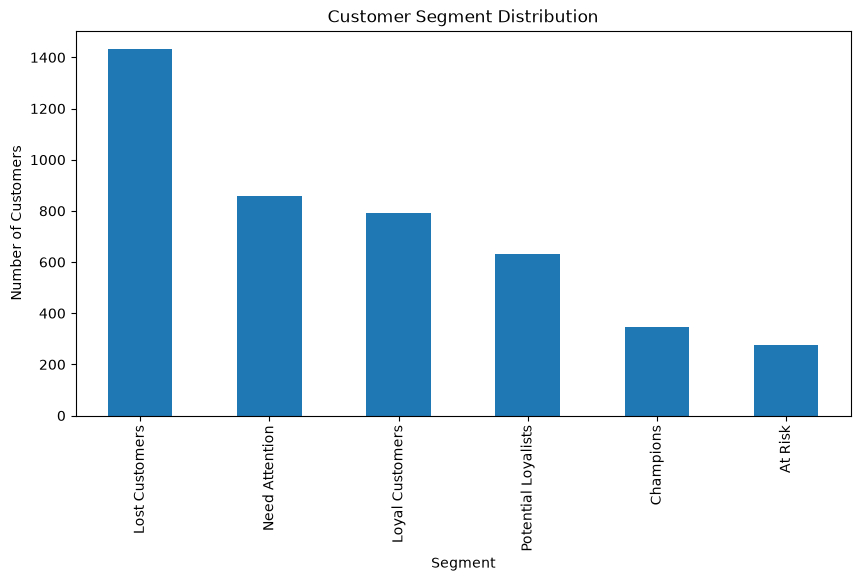

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Segment")

plt.show()

In [31]:
rfm.reset_index(inplace=True)

rfm.to_csv(
    "../data/processed/rfm_table.csv",
    index=False
)

future_df.to_csv(
    "../data/processed/future_transactions.csv",
    index=False
)

# RFM Conclusion

RFM analysis transformed transaction-level sales data into customer-level behavioral features using **Recency, Frequency, Monetary, and Average Order Value** metrics calculated from the observation window. This time-based approach ensures that customer features are derived exclusively from historical purchasing behavior, preventing target leakage in subsequent predictive models.

The rule-based RFM segmentation identified distinct customer groups, including **Champions, Loyal Customers, Potential Loyalists, Need Attention, At Risk, and Lost Customers**, enabling targeted customer retention, personalized marketing, and revenue optimization strategies.

The resulting RFM dataset serves as the foundation for the remaining stages of the Customer Intelligence & Revenue Growth pipeline, including **Customer Persona Discovery (KMeans), Churn Prediction, Customer Lifetime Value (CLV) Prediction, Revenue-at-Risk Analysis, and the AI Recommendation Engine**, providing a robust and business-oriented framework for customer analytics.
